In [1]:
import os
# Restore rclone on every kernel restart
if os.path.exists('/workspace/rclone.conf'):
    os.makedirs('/root/.config/rclone', exist_ok=True)
    os.system('cp /workspace/rclone.conf /root/.config/rclone/rclone.conf')
    print(' rclone restored')
else:
    print(' No rclone config — run terminal setup first')

 rclone restored


In [2]:
import os, subprocess

# Save everything locally on Vast.ai
BASE_DIR    = '/workspace/ResidualExperiment/'
CKPT_DIR    = BASE_DIR + 'checkpoints/'
FIG_DIR     = BASE_DIR + 'figures/'
RESULTS_DIR = BASE_DIR + 'results/'
LOCAL_DATA  = '/workspace/owt_cache/'

for d in [CKPT_DIR, FIG_DIR, RESULTS_DIR, LOCAL_DATA]:
    os.makedirs(d, exist_ok=True)

# Move existing checkpoints to correct location
old_ckpts = '/ResidualExperiment/Untitled Folder/'
if os.path.exists(old_ckpts):
    for f in os.listdir(old_ckpts):
        if f.endswith('.pt'):
            src = os.path.join(old_ckpts, f)
            dst = os.path.join(CKPT_DIR, f)
            subprocess.run(f'mv "{src}" "{dst}"', shell=True)
            print(f'   Moved {f}')

# Check disk space
r = subprocess.run('df -h /workspace', shell=True,
                   capture_output=True, text=True)
print(f'Disk: {r.stdout.split()[10]} used of {r.stdout.split()[9]}')

print('\n Workspace ready')
print(f'   Checkpoints : {CKPT_DIR}')
print(f'   Figures     : {FIG_DIR}')

# Show existing checkpoints
ckpts = [f for f in os.listdir(CKPT_DIR) if f.endswith('.pt')]
if ckpts:
    print(f'\n Checkpoints found:')
    for f in sorted(ckpts):
        size = os.path.getsize(os.path.join(CKPT_DIR,f))/1e9
        print(f'    {f} — {size:.2f} GB')
else:
    print('\n No checkpoints yet')

Disk: 53G used of 8.4G

 Workspace ready
   Checkpoints : /workspace/ResidualExperiment/checkpoints/
   Figures     : /workspace/ResidualExperiment/figures/

 Checkpoints found:
    ckpt_Attn_Only_Res.pt — 1.49 GB
    ckpt_FFN_Only_Res.pt — 1.49 GB
    ckpt_Full_Residual.pt — 1.49 GB
    ckpt_No_Residual.pt — 1.49 GB


In [3]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

for pkg in ['datasets','transformers','tiktoken','psutil']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        install(pkg)

r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode==0 else ' No GPU')


Fri May 22 21:24:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:83:00.0 Off |                    0 |
| N/A   39C    P0             27W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
                       'matplotlib', 'datasets', 'tiktoken', 
                       'psutil', 'transformers', '-q'])
print(' All packages installed')

 All packages installed


In [5]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import time, os, json, math, psutil, shutil
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from contextlib import nullcontext
from IPython.display import display, Image as IPImage, clear_output
import warnings; warnings.filterwarnings('ignore')

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype   = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32':torch.float32,'bfloat16':torch.bfloat16,'float16':torch.float16}[dtype]
ctx     = torch.amp.autocast(device_type='cuda',dtype=ptdtype) if device=='cuda' else nullcontext()

print(f'Device : {device.upper()}')
print(f'Dtype  : {dtype}')
if device=='cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'RAM    : {psutil.virtual_memory().total/1e9:.1f} GB')


Device : CUDA
Dtype  : bfloat16
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
RAM    : 1082.0 GB


In [6]:
# Fix variable names for local Vast.ai setup
DRIVE_DATA  = '/workspace/owt_cache/'
LOCAL_DATA  = '/workspace/owt_cache/'
BASE_DIR    = '/workspace/ResidualExperiment/'
CKPT_DIR    = BASE_DIR + 'checkpoints/'
FIG_DIR     = BASE_DIR + 'figures/'
RESULTS_DIR = BASE_DIR + 'results/'

import os
for d in [CKPT_DIR, FIG_DIR, RESULTS_DIR, LOCAL_DATA]:
    os.makedirs(d, exist_ok=True)

print(' All variables set')
print(f'   DRIVE_DATA  : {DRIVE_DATA}')
print(f'   LOCAL_DATA  : {LOCAL_DATA}')
print(f'   CKPT_DIR    : {CKPT_DIR}')
print(f'   FIG_DIR     : {FIG_DIR}')
print(f'   RESULTS_DIR : {RESULTS_DIR}')

 All variables set
   DRIVE_DATA  : /workspace/owt_cache/
   LOCAL_DATA  : /workspace/owt_cache/
   CKPT_DIR    : /workspace/ResidualExperiment/checkpoints/
   FIG_DIR     : /workspace/ResidualExperiment/figures/
   RESULTS_DIR : /workspace/ResidualExperiment/results/


In [7]:
import json, os, numpy as np

# Check what's in owt_cache
print('Files in owt_cache:')
for f in os.listdir('/workspace/owt_cache/'):
    size = os.path.getsize(f'/workspace/owt_cache/{f}')
    print(f'  {f} — {size/1e6:.1f} MB')

# Create meta.json based on actual file size
train_bin = '/workspace/owt_cache/train.bin'
val_bin   = '/workspace/owt_cache/val.bin'

train_tokens = os.path.getsize(train_bin) // 2  # uint16 = 2 bytes
val_tokens   = os.path.getsize(val_bin)   // 2

meta = {'train_tokens': train_tokens, 'val_tokens': val_tokens}

with open('/workspace/owt_cache/meta.json', 'w') as f:
    json.dump(meta, f)

print(f'\n meta.json created')
print(f'   Train tokens: {train_tokens/1e9:.3f}B')
print(f'   Val tokens  : {val_tokens/1e6:.1f}M')

Files in owt_cache:
  train.bin — 225.7 MB
  val.bin — 0.2 MB
  meta.json — 0.0 MB

 meta.json created
   Train tokens: 0.113B
   Val tokens  : 0.1M


In [8]:
import tiktoken
from datasets import load_dataset

enc        = tiktoken.get_encoding('gpt2')
VOCAB_SIZE = enc.n_vocab
print(f'Tokenizer: GPT-2 BPE | Vocab: {VOCAB_SIZE:,}')

def get_data(drive_cache=DRIVE_DATA, local_cache=LOCAL_DATA, target_docs=100_000):
    train_drive = os.path.join(drive_cache,'train.bin')
    val_drive   = os.path.join(drive_cache,'val.bin')
    train_local = os.path.join(local_cache,'train.bin')
    val_local   = os.path.join(local_cache,'val.bin')
    meta_file   = os.path.join(drive_cache,'meta.json')

    # Step 1: Download and tokenize if not on Drive
    if not os.path.exists(train_drive) or os.path.getsize(train_drive) < 1e6:
        os.makedirs(drive_cache, exist_ok=True)
        print(' Downloading OpenWebText...')
        dataset = load_dataset('openwebtext', split='train', streaming=True)
        train_tokens, val_tokens = [], []
        n_docs = 0
        for doc in dataset:
            tokens = enc.encode_ordinary(doc['text'])
            tokens.append(enc.eot_token)
            if n_docs % 1000 == 0:
                val_tokens.extend(tokens)
            else:
                train_tokens.extend(tokens)
            n_docs += 1
            if n_docs % 5000 == 0:
                print(f'   {n_docs:,} docs | {len(train_tokens)/1e6:.0f}M tokens',end='\r')
            if n_docs >= target_docs:
                break
        print(f'\n {len(train_tokens)/1e9:.3f}B train | {len(val_tokens)/1e6:.1f}M val')
        np.array(train_tokens,dtype=np.uint16).tofile(train_drive)
        np.array(val_tokens,  dtype=np.uint16).tofile(val_drive)
        with open(meta_file,'w') as f:
            json.dump({'train_tokens':len(train_tokens),'val_tokens':len(val_tokens)},f)
        print('Saved to Google Drive permanently')
    else:
        with open(meta_file) as f: meta=json.load(f)
        print(f' Drive cache: {meta["train_tokens"]/1e9:.3f}B train tokens')

    # Step 2: Copy to local for fast batch loading
    if not os.path.exists(train_local) or os.path.getsize(train_local)<1e6:
        os.makedirs(local_cache,exist_ok=True)
        print(' Copying Drive→local for fast training...')
        shutil.copy2(train_drive,train_local)
        shutil.copy2(val_drive,  val_local)
        print(' Local copy ready')
    else:
        print(' Local cache ready')

    train_data = np.memmap(train_local,dtype=np.uint16,mode='r')
    val_data   = np.memmap(val_local,  dtype=np.uint16,mode='r')
    return (torch.from_numpy(train_data.astype(np.int64)),
            torch.from_numpy(val_data.astype(np.int64)))

train_data, val_data = get_data()
print(f'Ready: {len(train_data)/1e9:.3f}B train | {len(val_data)/1e6:.1f}M val tokens')


Tokenizer: GPT-2 BPE | Vocab: 50,257
 Drive cache: 0.113B train tokens
 Local cache ready
Ready: 0.113B train | 0.1M val tokens


In [9]:
# ── Model ─────────────────────────────────────────────────────────
N_LAYER  = 12
N_EMBD   = 768
N_HEAD   = 12
DROPOUT  = 0.1

# ── Training ──────────────────────────────────────────────────────
BATCH_SIZE    = 16
BLOCK_SIZE    = 1024
GRAD_ACCUM    = 8
MAX_ITERS     = 20_000
EVAL_INTERVAL = 500
EVAL_ITERS    = 100

# ── LR schedule ───────────────────────────────────────────────────
MAX_LR         = 6e-4
MIN_LR         = MAX_LR / 10
WARMUP_ITERS   = 2_000
LR_DECAY_ITERS = MAX_ITERS

# ── Misc ──────────────────────────────────────────────────────────
SEED          = 1337
USE_GRAD_CKPT = True

# ── Research configs ──────────────────────────────────────────────
CONFIGS = [
    {'name':'Full_Residual', 'attn_res':True,  'ffn_res':True,  'color':'#00d4ff'},
    {'name':'No_Residual',   'attn_res':False, 'ffn_res':False, 'color':'#ff6b6b'},
    {'name':'Attn_Only_Res', 'attn_res':True,  'ffn_res':False, 'color':'#a9e34b'},
    {'name':'FFN_Only_Res',  'attn_res':False, 'ffn_res':True,  'color':'#ffd43b'},
]

BG,PANEL,GRID,TXT = '#0f0f1a','#1a1a2e','#2a2a4a','#e0e0f0'
tokens_per_step = BATCH_SIZE * BLOCK_SIZE * GRAD_ACCUM

print(f'Model     : {N_LAYER}L x {N_EMBD}d x {N_HEAD}H')
print(f'Eff batch : {tokens_per_step/1e3:.0f}k tokens/step')
print(f'Total     : {MAX_ITERS:,} steps = {MAX_ITERS*tokens_per_step/1e9:.2f}B tokens')
print(f'Configs   : {[c["name"] for c in CONFIGS]}')


Model     : 12L x 768d x 12H
Eff batch : 131k tokens/step
Total     : 20,000 steps = 2.62B tokens
Configs   : ['Full_Residual', 'No_Residual', 'Attn_Only_Res', 'FFN_Only_Res']


In [10]:
def get_lr(it):
    if it < WARMUP_ITERS: return MAX_LR * it / WARMUP_ITERS
    if it > LR_DECAY_ITERS: return MIN_LR
    decay = (it-WARMUP_ITERS)/(LR_DECAY_ITERS-WARMUP_ITERS)
    return MIN_LR + 0.5*(1+math.cos(math.pi*decay))*(MAX_LR-MIN_LR)

def get_batch(split):
    data = train_data if split=='train' else val_data
    ix   = torch.randint(len(data)-BLOCK_SIZE,(BATCH_SIZE,))
    x    = torch.stack([data[i  :i+BLOCK_SIZE  ].long() for i in ix])
    y    = torch.stack([data[i+1:i+BLOCK_SIZE+1].long() for i in ix])
    if device=='cuda':
        x=x.pin_memory().to(device,non_blocking=True)
        y=y.pin_memory().to(device,non_blocking=True)
    else:
        x,y=x.to(device),y.to(device)
    return x,y

print(' Ready')


 Ready


In [11]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert N_EMBD%N_HEAD==0
        self.c_attn    = nn.Linear(N_EMBD,3*N_EMBD,bias=False)
        self.c_proj    = nn.Linear(N_EMBD,N_EMBD,  bias=False)
        self.resid_drop= nn.Dropout(DROPOUT)
        self.n_head,self.n_embd = N_HEAD,N_EMBD

    def forward(self,x):
        B,T,C=x.shape
        q,k,v=self.c_attn(x).split(self.n_embd,dim=2)
        k=k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q=q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v=v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        y=F.scaled_dot_product_attention(q,k,v,attn_mask=None,
            dropout_p=DROPOUT if self.training else 0,is_causal=True)
        return self.resid_drop(self.c_proj(y.transpose(1,2).contiguous().view(B,T,C)))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(N_EMBD,4*N_EMBD,bias=False)
        self.act=nn.GELU()
        self.fc2=nn.Linear(4*N_EMBD,N_EMBD,bias=False)
        self.drop=nn.Dropout(DROPOUT)
        self._act_out=None  # instrumentation

    def forward(self,x):
        h=self.act(self.fc1(x))
        self._act_out=h.detach()
        return self.drop(self.fc2(h))

class Block(nn.Module):
    def __init__(self,attn_res=True,ffn_res=True):
        super().__init__()
        self.ln1=nn.LayerNorm(N_EMBD); self.ln2=nn.LayerNorm(N_EMBD)
        self.attn=CausalSelfAttention(); self.ffwd=FeedForward()
        self.attn_res=attn_res; self.ffn_res=ffn_res
        self._h_norm=None  # instrumentation

    def forward(self,x):
        sa=self.attn(self.ln1(x)); x=x+sa if self.attn_res else sa
        ff=self.ffwd(self.ln2(x)); x=x+ff if self.ffn_res  else ff
        self._h_norm=x.detach().norm(2,dim=-1).mean().item()
        return x

class GPT(nn.Module):
    def __init__(self,attn_res=True,ffn_res=True):
        super().__init__()
        self.tok_emb=nn.Embedding(VOCAB_SIZE,N_EMBD)
        self.pos_emb=nn.Embedding(BLOCK_SIZE,N_EMBD)
        self.drop=nn.Dropout(DROPOUT)
        self.blocks=nn.ModuleList([Block(attn_res,ffn_res) for _ in range(N_LAYER)])
        self.ln_f=nn.LayerNorm(N_EMBD)
        self.lm_head=nn.Linear(N_EMBD,VOCAB_SIZE,bias=False)
        self.tok_emb.weight=self.lm_head.weight
        self.use_grad_ckpt=USE_GRAD_CKPT
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Linear):
                torch.nn.init.normal_(m.weight,0.0,0.02)
                if m.bias is not None: torch.nn.init.zeros_(m.bias)
            elif isinstance(m,nn.Embedding):
                torch.nn.init.normal_(m.weight,0.0,0.02)
        for pn,p in self.named_parameters():
            if pn.endswith('c_proj.weight') or pn.endswith('fc2.weight'):
                torch.nn.init.normal_(p,0.0,0.02/math.sqrt(2*N_LAYER))

    def forward(self,idx,targets=None):
        B,T=idx.shape
        x=self.drop(self.tok_emb(idx)+self.pos_emb(torch.arange(T,device=device)))
        for block in self.blocks:
            if self.use_grad_ckpt and self.training:
                x=torch.utils.checkpoint.checkpoint(block,x,use_reentrant=False)
            else: x=block(x)
        logits=self.lm_head(self.ln_f(x))
        loss=F.cross_entropy(logits.view(-1,logits.size(-1)),targets.view(-1)) if targets is not None else None
        return logits,loss

    def get_ffn_layers(self): return [b.ffwd for b in self.blocks]
    def get_blocks(self):     return list(self.blocks)
    def n_params(self):       return sum(p.numel() for p in self.parameters())/1e6

_m=GPT()
N_PARAMS = _m.n_params()
print(f' Model: {N_PARAMS:.1f}M parameters')
del _m


 Model: 124.4M parameters


In [12]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out={}
    for split in ['train','val']:
        losses=[]
        for _ in range(EVAL_ITERS):
            xb,yb=get_batch(split)
            with ctx: _,loss=model(xb,yb)
            losses.append(loss.item())
        out[split]=float(np.mean(losses))
    model.train(); return out

@torch.no_grad()
def collect_activation_stats(model):
    model.eval(); xb,yb=get_batch('train')
    with ctx: model(xb,yb)
    stats={}
    for i,ffn in enumerate(model.get_ffn_layers()):
        flat=ffn._act_out.float().cpu().reshape(-1).numpy()
        stats[str(i)]={'dead':float((flat<=0).mean()),
                       'near_zero':float((np.abs(flat)<0.01).mean()),
                       'mean':float(flat.mean()),'std':float(flat.std())}
    model.train(); return stats

def collect_gradient_norms(model):
    norms={}
    for i,ffn in enumerate(model.get_ffn_layers()):
        g1,g2=ffn.fc1.weight.grad,ffn.fc2.weight.grad
        if g1 is not None and g2 is not None:
            norms[str(i)]={'fc1':g1.norm(2).item(),'fc2':g2.norm(2).item()}
    return norms

@torch.no_grad()
def collect_hidden_norms(model):
    model.eval(); xb,yb=get_batch('train')
    with ctx: model(xb,yb)
    norms={str(i):b._h_norm for i,b in enumerate(model.get_blocks())}
    model.train(); return norms

def collect_weight_norms(model):
    norms={}
    for i,ffn in enumerate(model.get_ffn_layers()):
        w1,w2=ffn.fc1.weight.data.norm(2).item(),ffn.fc2.weight.data.norm(2).item()
        norms[str(i)]={'fc1':w1,'fc2':w2,'mean':(w1+w2)/2}
    return norms

print(' Metric collectors ready')


 Metric collectors ready


In [13]:
def ckpt_path(cfg_name):
    return os.path.join(CKPT_DIR, f'ckpt_{cfg_name}.pt')

def save_checkpoint(step, model, optimizer, scaler, stats, cfg_name):
    """Save checkpoint directly to Google Drive."""
    path = ckpt_path(cfg_name)
    torch.save({
        'step':step,
        'model':model.state_dict(),
        'optimizer':optimizer.state_dict(),
        'scaler':scaler.state_dict() if scaler else None,
        'stats':stats,
        'cfg_name':cfg_name,
    }, path)
    # Verify save succeeded
    if os.path.exists(path):
        size = os.path.getsize(path)/1e9
        print(f'   Checkpoint saved → Drive ({size:.2f} GB)')
    else:
        print(f'   Checkpoint save FAILED for {cfg_name}')

def load_checkpoint(cfg_name, model, optimizer, scaler):
    """Load checkpoint from Google Drive — works after any disconnect."""
    path = ckpt_path(cfg_name)
    if not os.path.exists(path):
        print(f'  No checkpoint for {cfg_name} — starting from scratch')
        return 0, {}
    try:
        ckpt = torch.load(path, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        if scaler and ckpt.get('scaler'):
            scaler.load_state_dict(ckpt['scaler'])
        step = ckpt['step']
        print(f'   Resumed {cfg_name} from step {step:,}')
        return step, ckpt['stats']
    except Exception as e:
        print(f'   Could not load checkpoint: {e}')
        return 0, {}

print(' Checkpoint system ready')
print(f'   Saving to: {CKPT_DIR}')

# Show existing checkpoints
ckpts = [f for f in os.listdir(CKPT_DIR) if f.endswith('.pt')]
if ckpts:
    print(f'\n Found {len(ckpts)} existing checkpoint(s):')
    for f in sorted(ckpts):
        size = os.path.getsize(os.path.join(CKPT_DIR,f))/1e9
        print(f'    {f} ({size:.2f} GB)')


 Checkpoint system ready
   Saving to: /workspace/ResidualExperiment/checkpoints/

 Found 4 existing checkpoint(s):
    ckpt_Attn_Only_Res.pt (1.49 GB)
    ckpt_FFN_Only_Res.pt (1.49 GB)
    ckpt_Full_Residual.pt (1.49 GB)
    ckpt_No_Residual.pt (1.49 GB)


In [14]:
def save_dashboard(cfg, step, lr,
                   iters_log, train_losses, val_losses, lr_log,
                   gpu_mems, tok_rates,
                   grad_norm_history, hidden_norm_history,
                   act_stats_history, weight_norm_history,
                   completed_runs, is_final=False):

    run_name=cfg['name']; color=cfg['color']
    ppl=[math.exp(min(v,20)) for v in val_losses]

    fig=plt.figure(figsize=(26,18))
    fig.patch.set_facecolor(BG)

    title_color = '#ffd700' if is_final else TXT
    prefix = ' FINAL RESULT  ' if is_final else ''
    fig.suptitle(
        f'{prefix}Residual Study — OpenWebText {N_PARAMS:.1f}M params |  {run_name}  |  '
        f'Step {step:,}/{MAX_ITERS:,}  |  LR {lr:.2e}  |  {device.upper()}',
        color=title_color, fontsize=12 if is_final else 11,
        fontweight='bold', y=0.98)

    gs=gridspec.GridSpec(4,4,figure=fig,hspace=0.65,wspace=0.38)

    def ax_(r,c,cs=1): return fig.add_subplot(gs[r,c:c+cs])
    def style(ax,title,xlabel='Step',ylabel=''):
        ax.set_facecolor(PANEL)
        for s in ax.spines.values(): s.set_color(GRID)
        ax.tick_params(colors=TXT,labelsize=8)
        ax.set_title(title,color=TXT,fontsize=9,fontweight='bold',pad=5)
        ax.grid(True,color=GRID,linewidth=0.4,linestyle='--')
        if xlabel: ax.set_xlabel(xlabel,color=TXT,fontsize=8)
        if ylabel: ax.set_ylabel(ylabel,color=TXT,fontsize=8)

    # Row 0: Loss + All-config comparison
    ax_loss=ax_(0,0,cs=2); ax_cmp=ax_(0,2,cs=2)
    style(ax_loss,f'{run_name} — Train & Val Loss',ylabel='Loss')
    if iters_log:
        ax_loss.plot(iters_log,train_losses,color=color,lw=2,marker='o',ms=3,
                     label=f'Train {train_losses[-1]:.4f}')
        ax_loss.plot(iters_log,val_losses,'w--',lw=2,marker='s',ms=3,
                     label=f'Val   {val_losses[-1]:.4f}')
        ax_loss.fill_between(iters_log,train_losses,alpha=0.1,color=color)
        ax_loss.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=8)
    ax_loss.set_xlim(0,MAX_ITERS)

    style(ax_cmp,'All Configs — Val Loss Comparison',ylabel='Val Loss')
    for cname,res in completed_runs.items():
        c2=next(c['color'] for c in CONFIGS if c['name']==cname)
        ax_cmp.plot(res['iters_log'],res['val_losses'],color=c2,lw=2,
                    label=f"{cname.replace('_',' ')} → {res['final_val']:.4f}")
    if val_losses:
        ax_cmp.plot(iters_log,val_losses,color=color,lw=2,linestyle=':',
                    label=f'{run_name} (live)')
    ax_cmp.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=7)
    ax_cmp.set_xlim(0,MAX_ITERS)

    # Row 1: LR, PPL, GPU, Throughput
    ax_lr=ax_(1,0); ax_ppl=ax_(1,1); ax_gpu=ax_(1,2); ax_tok=ax_(1,3)

    style(ax_lr,'LR Schedule',ylabel='LR')
    if lr_log: ax_lr.plot(iters_log,lr_log,color='#ff9f43',lw=2)
    ax_lr.set_xlim(0,MAX_ITERS)

    style(ax_ppl,'Validation Perplexity',ylabel='PPL')
    if ppl:
        ax_ppl.plot(iters_log,ppl,color='#ff6b9d',lw=2,marker='o',ms=3,
                    label=f'PPL {ppl[-1]:.1f}')
        ax_ppl.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=8)
    ax_ppl.set_xlim(0,MAX_ITERS)

    style(ax_gpu,f'GPU Mem [{gpu_mems[-1]:.0f}MB]' if gpu_mems else 'GPU Mem',ylabel='MB')
    if gpu_mems: ax_gpu.plot(iters_log,gpu_mems,color='#54a0ff',lw=2)
    ax_gpu.set_xlim(0,MAX_ITERS)

    style(ax_tok,f'Tok/sec [{tok_rates[-1]:,.0f}]' if tok_rates else 'Throughput',ylabel='tok/s')
    if tok_rates: ax_tok.plot(iters_log,tok_rates,color='#ffd43b',lw=2)
    ax_tok.set_xlim(0,MAX_ITERS)

    # Row 2: Gradient norms + Hidden state norms
    ax_grad=ax_(2,0,cs=2); ax_hn=ax_(2,2,cs=2)

    style(ax_grad,'Gradient Norm per FFN Layer (latest)',xlabel='Layer',ylabel='L2 Norm')
    if grad_norm_history:
        latest=grad_norm_history[-1]; layers=sorted(latest.keys(),key=int)
        x=np.arange(len(layers))
        ax_grad.bar(x-0.2,[latest[l]['fc1'] for l in layers],0.4,
                    color=color,alpha=0.85,label='fc1 (pre-act)')
        ax_grad.bar(x+0.2,[latest[l]['fc2'] for l in layers],0.4,
                    color='#888',alpha=0.85,label='fc2 (post-act)')
        ax_grad.set_xticks(x)
        ax_grad.set_xticklabels([f'L{l}' for l in layers],color=TXT,fontsize=7)
        ax_grad.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=8)

    style(ax_hn,'Hidden-State Norm by Depth (last 5 snapshots)',
          xlabel='Layer',ylabel='Mean ||h||₂')
    if hidden_norm_history:
        for si,snap in enumerate(hidden_norm_history[-5:]):
            lyrs=sorted(snap.keys(),key=int)
            ax_hn.plot(range(len(lyrs)),[snap[l] for l in lyrs],
                       color=color,alpha=0.3+0.14*si,lw=1.5,marker='o',ms=4)
        ax_hn.set_xticks(range(len(lyrs)))
        ax_hn.set_xticklabels([f'L{l}' for l in lyrs],color=TXT,fontsize=7)
    for cname,res in completed_runs.items():
        c2=next(c['color'] for c in CONFIGS if c['name']==cname)
        snap=res['hidden_norm_history'][-1]; lyrs=sorted(snap.keys(),key=int)
        ax_hn.plot(range(len(lyrs)),[snap[l] for l in lyrs],
                   color=c2,lw=2,linestyle='--',alpha=0.7,
                   label=cname.replace('_',' '))
    ax_hn.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=7)

    # Row 3: Dead neurons, Weight norms, Gen gap
    ax_dead=ax_(3,0,cs=2); ax_wt=ax_(3,2); ax_gap=ax_(3,3)

    style(ax_dead,'Dead Neuron Rate per Layer (% activations ≤ 0)',
          xlabel='Layer',ylabel='% Dead')
    if act_stats_history:
        latest=act_stats_history[-1]; layers=sorted(latest.keys(),key=int)
        x=np.arange(len(layers))
        bars=ax_dead.bar(x,[latest[l]['dead']*100 for l in layers],
                         color=color,alpha=0.85,edgecolor=GRID)
        for bar,l in zip(bars,layers):
            ax_dead.text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()+0.5,
                         f'{latest[l]["dead"]*100:.1f}%',
                         ha='center',color=TXT,fontsize=7)
        for cname,res in completed_runs.items():
            c2=next(c['color'] for c in CONFIGS if c['name']==cname)
            snap=res['act_stats_history'][-1]; lyrs=sorted(snap.keys(),key=int)
            ax_dead.plot(range(len(lyrs)),
                         [snap[l]['dead']*100 for l in lyrs],
                         color=c2,lw=2,linestyle='--',marker='o',ms=4,
                         alpha=0.7,label=cname.replace('_',' '))
        ax_dead.set_xticks(x)
        ax_dead.set_xticklabels([f'L{l}' for l in layers],color=TXT,fontsize=7)
        ax_dead.set_ylim(0,100)
        ax_dead.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=7)

    style(ax_wt,'Weight Norm per Layer',xlabel='Layer',ylabel='||W||₂')
    if weight_norm_history:
        latest=weight_norm_history[-1]; layers=sorted(latest.keys(),key=int)
        ax_wt.bar(range(len(layers)),[latest[l]['mean'] for l in layers],
                  color='#a29bfe',alpha=0.85)
        ax_wt.set_xticks(range(len(layers)))
        ax_wt.set_xticklabels([f'L{l}' for l in layers],color=TXT,fontsize=7)

    style(ax_gap,'Generalisation Gap (Val − Train)',ylabel='Gap')
    if iters_log and len(val_losses)==len(train_losses):
        gap=[v-t for v,t in zip(val_losses,train_losses)]
        ax_gap.plot(iters_log,gap,color=color,lw=2,marker='o',ms=3,
                    label=f'gap={gap[-1]:.4f}')
        ax_gap.axhline(0,color='white',lw=0.8,linestyle='--',alpha=0.3)
        for cname,res in completed_runs.items():
            c2=next(c['color'] for c in CONFIGS if c['name']==cname)
            g2=[v-t for v,t in zip(res['val_losses'],res['train_losses'])]
            ax_gap.plot(res['iters_log'],g2,color=c2,lw=1.5,
                        linestyle='--',alpha=0.6,label=cname.replace('_',' '))
        ax_gap.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=7)
        ax_gap.set_xlim(0,MAX_ITERS)

    plt.tight_layout(rect=[0,0,1,0.97])

    # ── Save to Google Drive ──────────────────────────────────────────
    if is_final:
        fname = f'FINAL_{run_name}.png'
    else:
        fname = f'{run_name}_step{step:05d}.png'

    savepath = os.path.join(FIG_DIR, fname)
    plt.savefig(savepath, dpi=130, bbox_inches='tight', facecolor=BG)

    # ── Display in notebook ───────────────────────────────────────────
    try:
        clear_output(wait=True)
        display(IPImage(savepath))
    except:
        pass
    plt.close()
    print(f'   {" FINAL" if is_final else "Step"} photo saved → {savepath}')

print('Dashboard system ready')
print(f'   Photos save to: {FIG_DIR}')


Dashboard system ready
   Photos save to: /workspace/ResidualExperiment/figures/


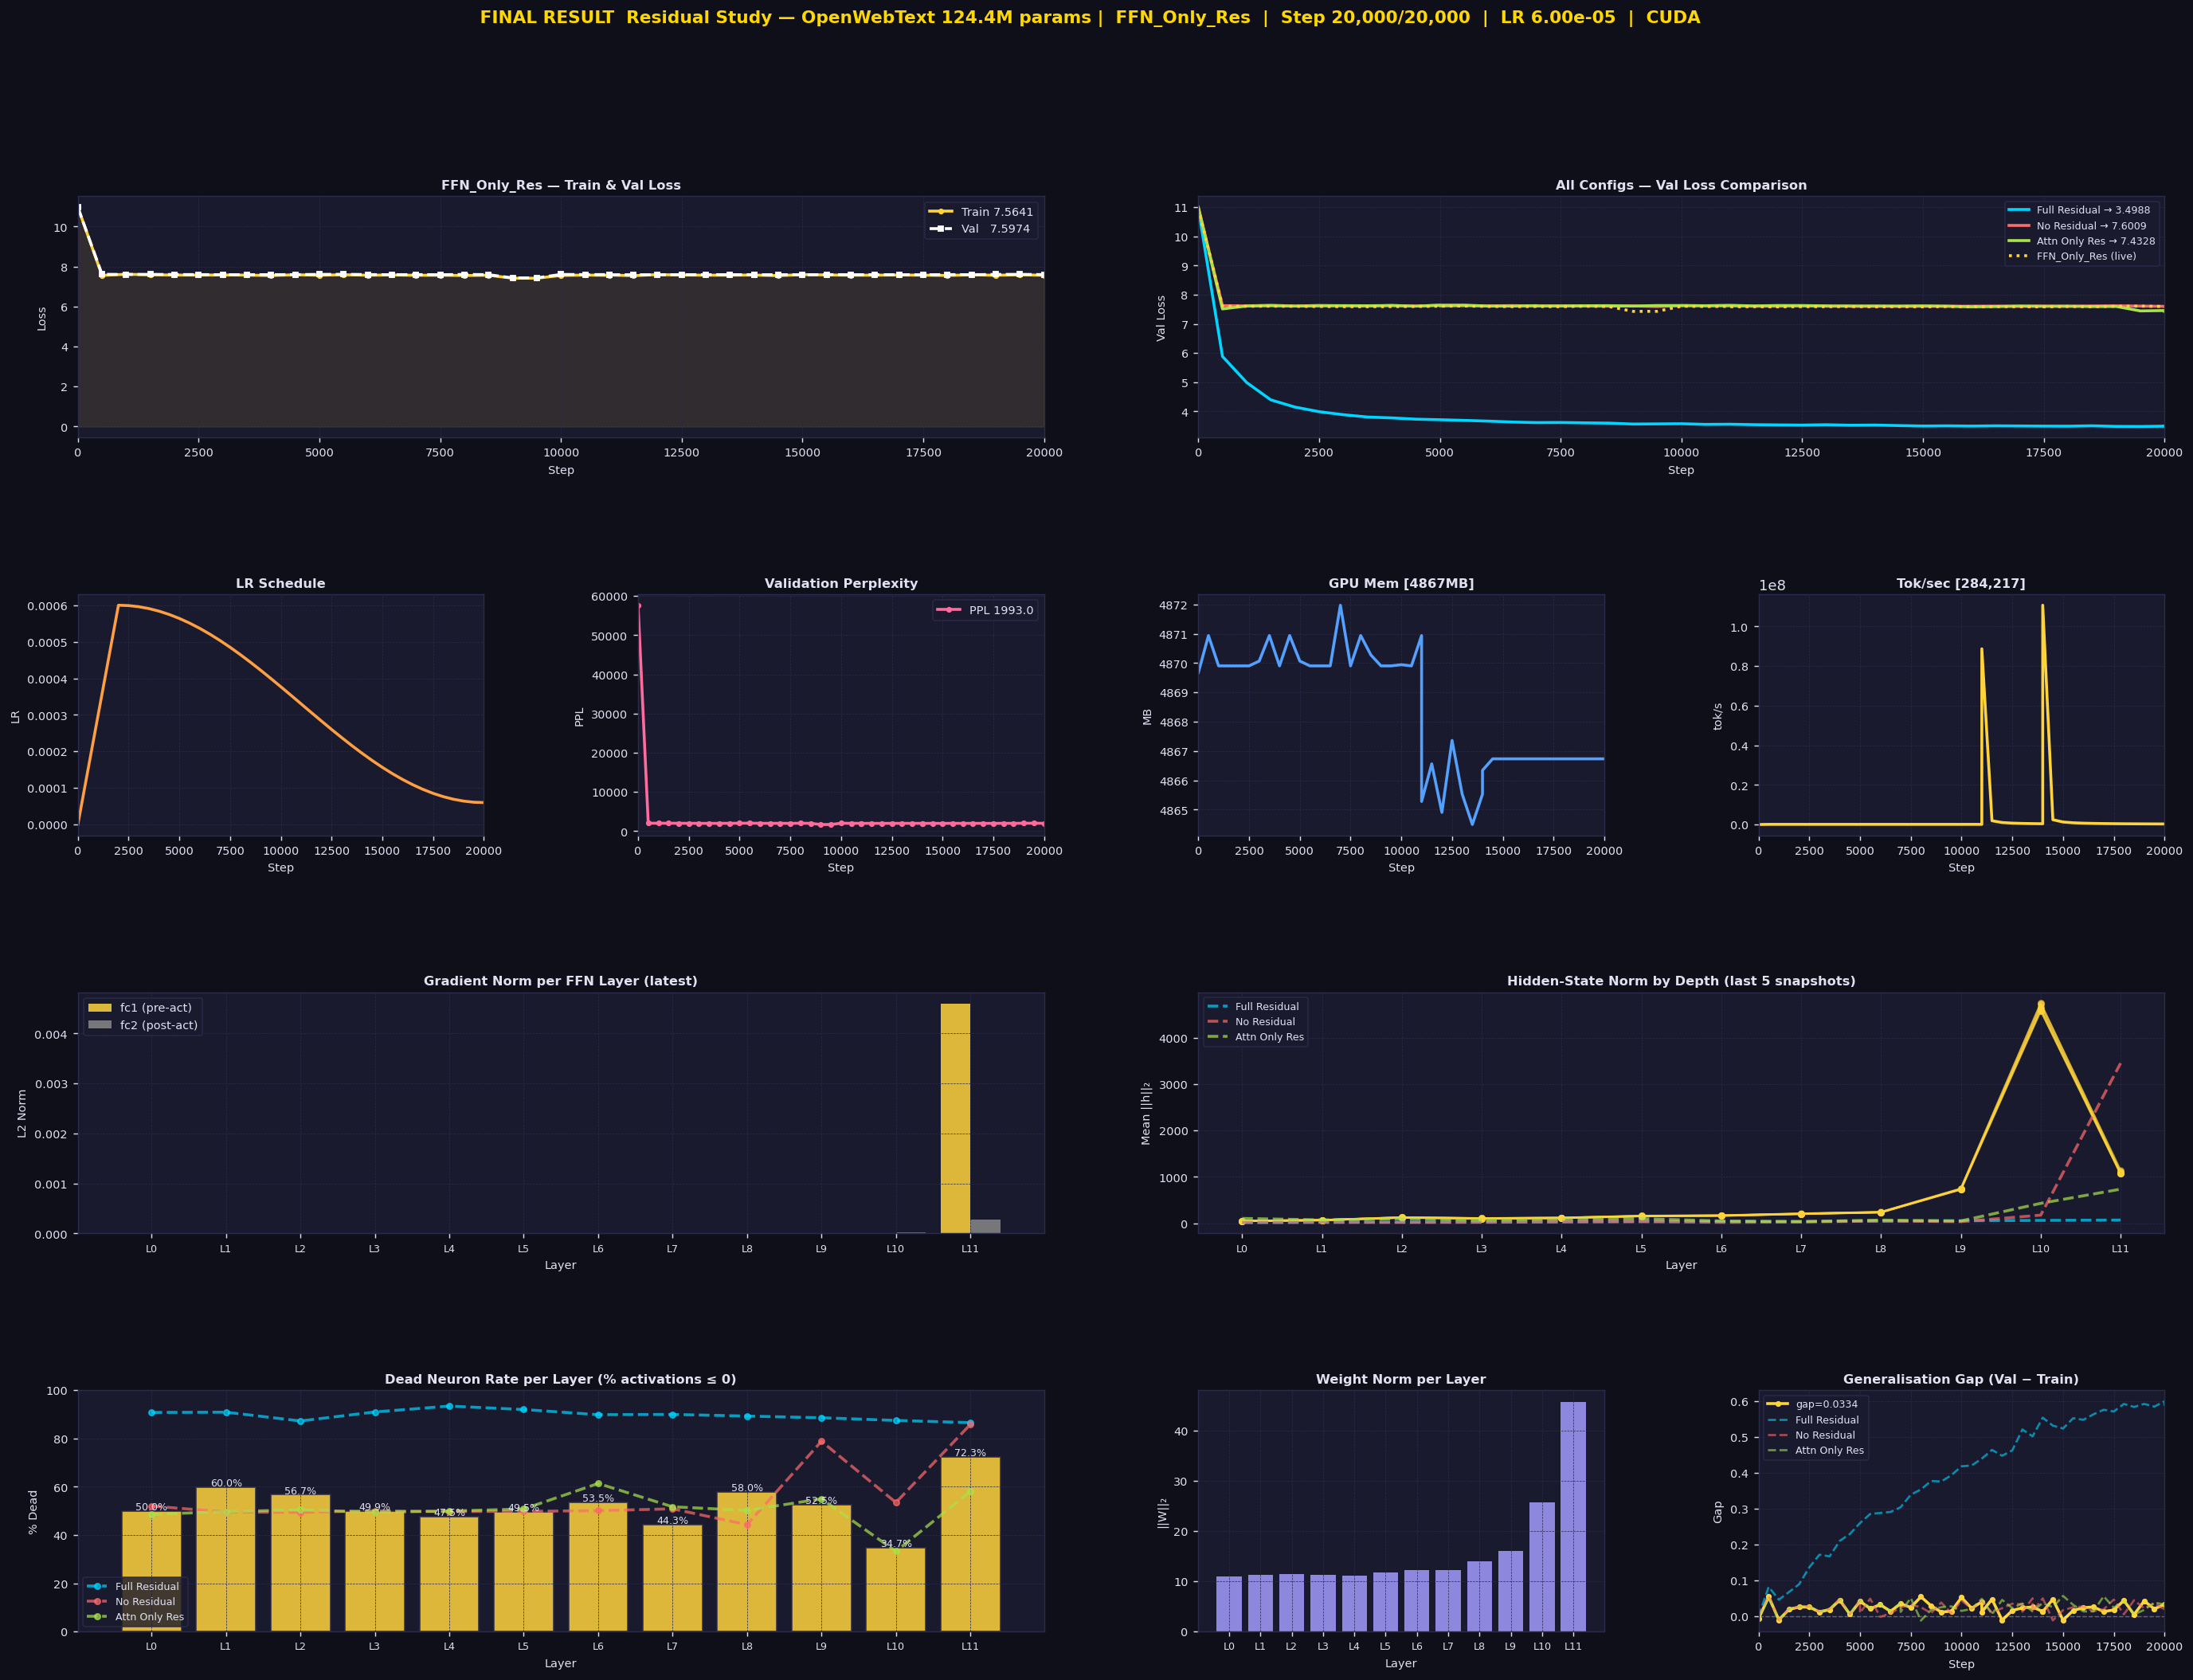

    FINAL photo saved → /workspace/ResidualExperiment/figures/FINAL_FFN_Only_Res.png
   Results saved → /workspace/ResidualExperiment/results/residual_results_owt.json
   FINAL_FFN_Only_Res.png saved → /workspace/ResidualExperiment/figures/
  Final val: 7.5974 | PPL: 1993.0

═════════════════════════════════════════════════════════════════
  ALL CONFIGS COMPLETE
═════════════════════════════════════════════════════════════════
Config                 |   Val Loss |      PPL |      Train
──────────────────────────────────────────────────────────
Full Residual          |     3.4988 |     33.1 |     2.9030
No Residual            |     7.6009 |   2000.1 |     7.5878
Attn Only Res          |     7.4328 |   1690.6 |     7.4157
FFN Only Res           |     7.5974 |   1993.0 |     7.5641

 All results saved to Google Drive: /workspace/ResidualExperiment/results/
 All photos saved to Google Drive  : /workspace/ResidualExperiment/figures/


In [15]:
# ── Load completed results from Drive ────────────────────────────────
results_file = os.path.join(RESULTS_DIR, 'residual_results_owt.json')
all_results  = {}

if os.path.exists(results_file):
    with open(results_file) as f:
        all_results = json.load(f)
    completed = [n for n,r in all_results.items() if r.get('complete')]
    print(f' Loaded results from Drive')
    print(f'   Completed configs: {completed}')
else:
    print(' No results file yet — starting fresh')

scaler = torch.cuda.amp.GradScaler(enabled=(dtype=='float16'))

# ── Run each config ───────────────────────────────────────────────────────
for cfg in CONFIGS:
    run_name = cfg['name']
    color    = cfg['color']

    # Skip if already complete
    if run_name in all_results and all_results[run_name].get('complete', False):
        print(f'\n⏭  {run_name} already complete '
              f'(val={all_results[run_name]["final_val"]:.4f}) — skipping')
        continue

    print(f'\n{"═"*65}')
    print(f'  Config   : {run_name}')
    print(f'  attn_res : {cfg["attn_res"]}  |  ffn_res: {cfg["ffn_res"]}')
    print(f'{"═"*65}')

    torch.manual_seed(SEED)
    if device=='cuda': torch.cuda.manual_seed(SEED)

    model     = GPT(attn_res=cfg['attn_res'],ffn_res=cfg['ffn_res']).to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=MAX_LR,
                                   betas=(0.9,0.95),weight_decay=0.1)
    print(f'  Params   : {model.n_params():.1f}M')

    # ── Auto-resume from Google Drive ────────────────────────────────
    start_step, saved = load_checkpoint(run_name, model, optimizer, scaler)

    iters_log           = saved.get('iters_log',[])
    train_losses        = saved.get('train_losses',[])
    val_losses          = saved.get('val_losses',[])
    lr_log              = saved.get('lr_log',[])
    gpu_mems            = saved.get('gpu_mems',[])
    tokens_list         = saved.get('tokens_list',[])
    tok_rates           = saved.get('tok_rates',[])
    grad_norm_history   = saved.get('grad_norm_history',[])
    hidden_norm_history = saved.get('hidden_norm_history',[])
    act_stats_history   = saved.get('act_stats_history',[])
    weight_norm_history = saved.get('weight_norm_history',[])

    tokens_processed = start_step * tokens_per_step
    t0 = time.time()

    # ── Training ──────────────────────────────────────────────────────
    for it in range(start_step, MAX_ITERS):
        lr = get_lr(it)
        for pg in optimizer.param_groups: pg['lr'] = lr

        optimizer.zero_grad(set_to_none=True)
        for _ in range(GRAD_ACCUM):
            xb,yb = get_batch('train')
            with ctx: _,loss = model(xb,yb)
            scaler.scale(loss/GRAD_ACCUM).backward()

        gnorms = collect_gradient_norms(model)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        scaler.step(optimizer); scaler.update()
        tokens_processed += tokens_per_step

        # ── Eval + Save ───────────────────────────────────────────────
        if it % EVAL_INTERVAL == 0 or it == MAX_ITERS-1:
            losses  = estimate_loss(model)
            astats  = collect_activation_stats(model)
            hnorms  = collect_hidden_norms(model)
            wnorms  = collect_weight_norms(model)
            elapsed = time.time()-t0

            gpu_mb = torch.cuda.memory_allocated()/1e6 if device=='cuda' else 0.0
            tok_s  = tokens_processed/max(elapsed,1)
            ppl    = math.exp(min(losses['val'],20))
            gap    = losses['val']-losses['train']

            iters_log.append(it)
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            lr_log.append(lr)
            gpu_mems.append(gpu_mb)
            tokens_list.append(tokens_processed)
            tok_rates.append(tok_s)
            grad_norm_history.append(gnorms)
            hidden_norm_history.append(hnorms)
            act_stats_history.append(astats)
            weight_norm_history.append(wnorms)

            print(f'  step {it:>5,} | '
                  f'train {losses["train"]:.4f} | '
                  f'val {losses["val"]:.4f} | '
                  f'ppl {ppl:.1f} | '
                  f'gap {gap:+.4f} | '
                  f'lr {lr:.2e} | '
                  f'{tok_s:,.0f} tok/s')

            stats_snap = {
                'iters_log':iters_log,
                'train_losses':train_losses,
                'val_losses':val_losses,
                'lr_log':lr_log,
                'gpu_mems':gpu_mems,
                'tokens_list':tokens_list,
                'tok_rates':tok_rates,
                'grad_norm_history':grad_norm_history,
                'hidden_norm_history':hidden_norm_history,
                'act_stats_history':act_stats_history,
                'weight_norm_history':weight_norm_history,
            }

            # ── Save checkpoint to Google Drive ───────────────────────
            save_checkpoint(it, model, optimizer, scaler, stats_snap, run_name)

            # ── Save dashboard photo to Google Drive ──────────────────
            save_dashboard(cfg, it, lr,
                           iters_log, train_losses, val_losses, lr_log,
                           gpu_mems, tok_rates, grad_norm_history,
                           hidden_norm_history, act_stats_history,
                           weight_norm_history, all_results, is_final=False)

    # ── Config complete ───────────────────────────────────────────────
    print(f'\n   {run_name} COMPLETE!')
    all_results[run_name] = {
        **stats_snap,
        'final_train' : train_losses[-1],
        'final_val'   : val_losses[-1],
        'final_ppl'   : math.exp(min(val_losses[-1],20)),
        'n_params'    : model.n_params(),
        'complete'    : True,
    }

    # ── Save FINAL dashboard photo ────────────────────────────────────
    save_dashboard(cfg, MAX_ITERS, lr,
                   iters_log, train_losses, val_losses, lr_log,
                   gpu_mems, tok_rates, grad_norm_history,
                   hidden_norm_history, act_stats_history,
                   weight_norm_history,
                   {k:v for k,v in all_results.items() if k!=run_name},
                   is_final=True)

    # ── Save results JSON to Drive ────────────────────────────────────
    with open(results_file,'w') as f:
        json.dump(all_results,f,indent=2)
    print(f'   Results saved → {results_file}')
    print(f'   FINAL_{run_name}.png saved → {FIG_DIR}')
    print(f'  Final val: {val_losses[-1]:.4f} | PPL: {math.exp(min(val_losses[-1],20)):.1f}')

    del model
    if device=='cuda': torch.cuda.empty_cache()

# ── All configs done ──────────────────────────────────────────────────────
print('\n' + '═'*65)
print('  ALL CONFIGS COMPLETE')
print('═'*65)
print(f'{"Config":<22} | {"Val Loss":>10} | {"PPL":>8} | {"Train":>10}')
print('─'*58)
for name,res in all_results.items():
    if res.get('complete'):
        print(f'{name.replace("_"," "):<22} | '
              f'{res["final_val"]:>10.4f} | '
              f'{res["final_ppl"]:>8.1f} | '
              f'{res["final_train"]:>10.4f}')
print(f'\n All results saved to Google Drive: {RESULTS_DIR}')
print(f' All photos saved to Google Drive  : {FIG_DIR}')


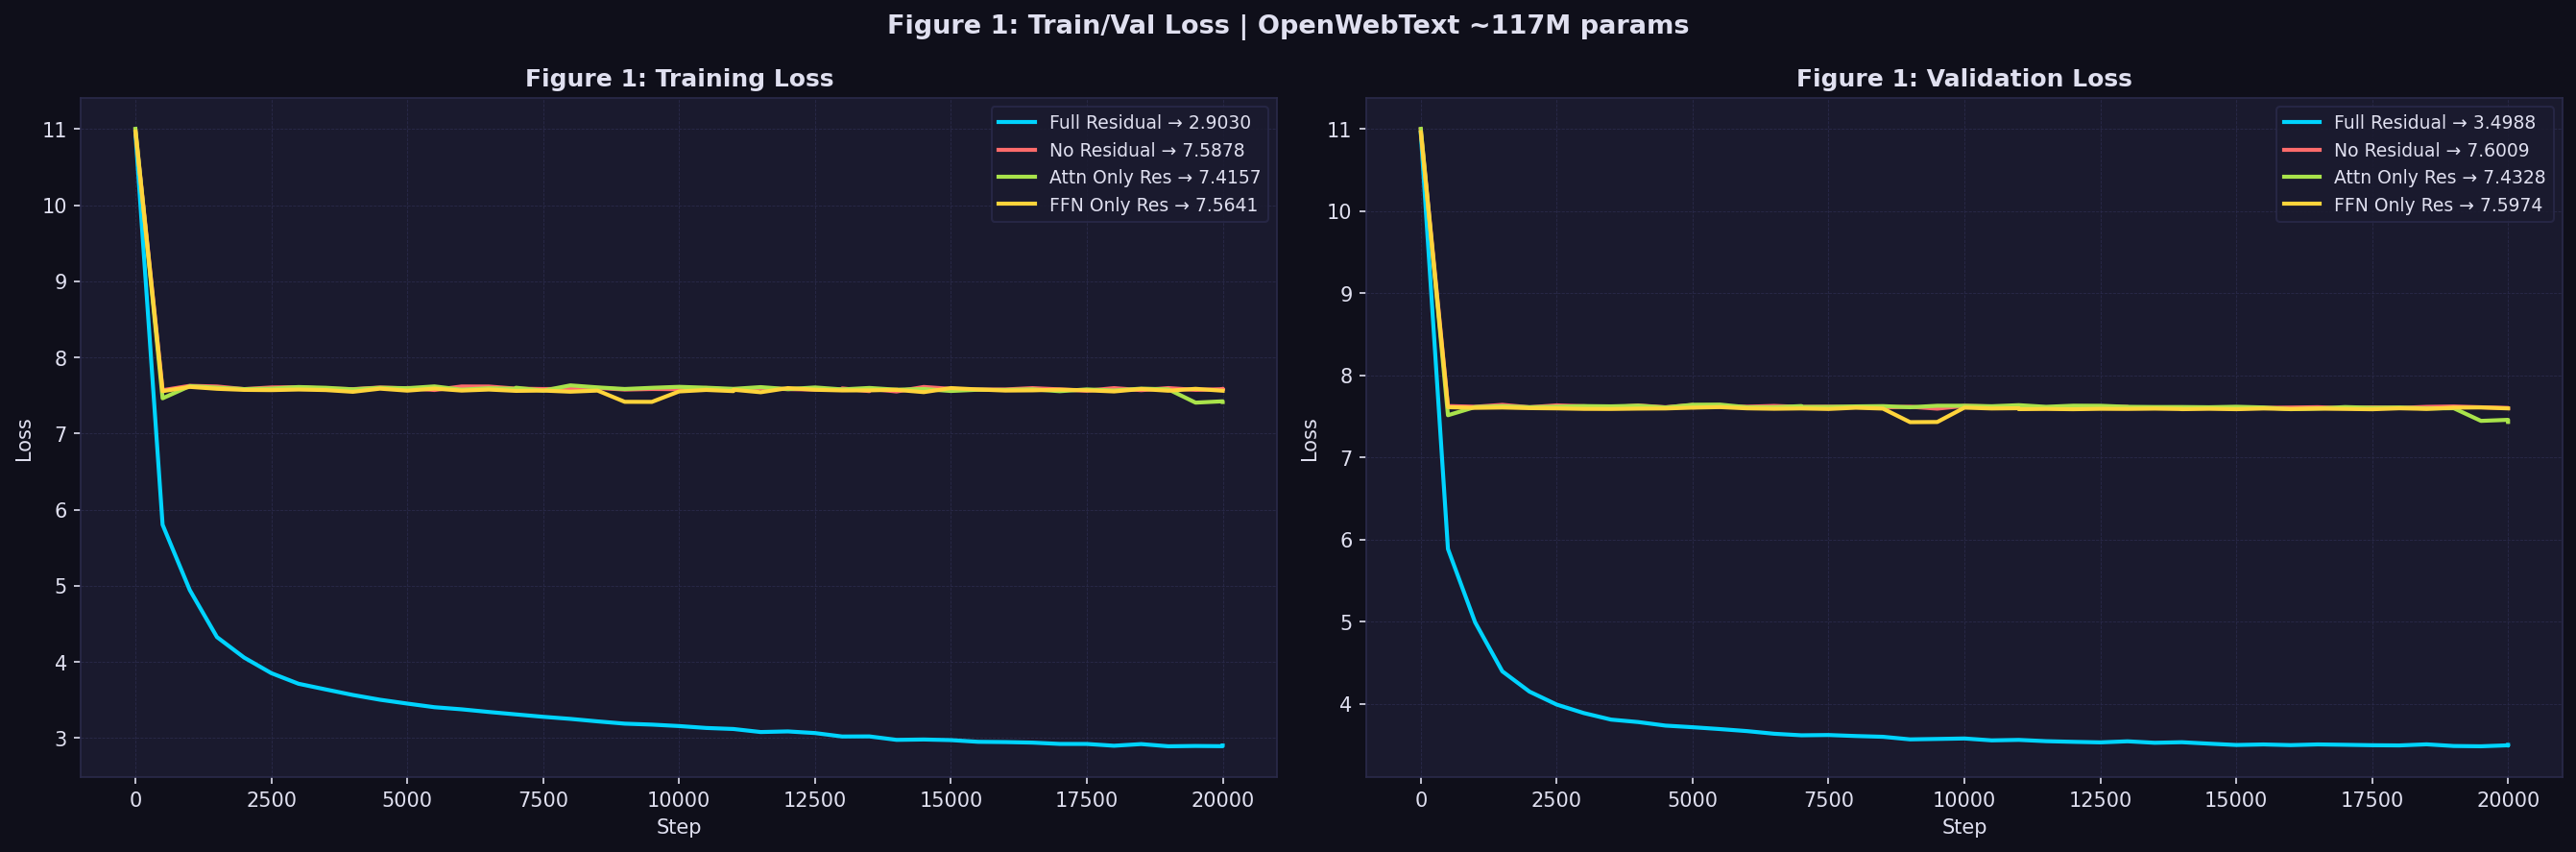

 PUB_fig1_loss_curves.png → /workspace/ResidualExperiment/figures/PUB_fig1_loss_curves.png


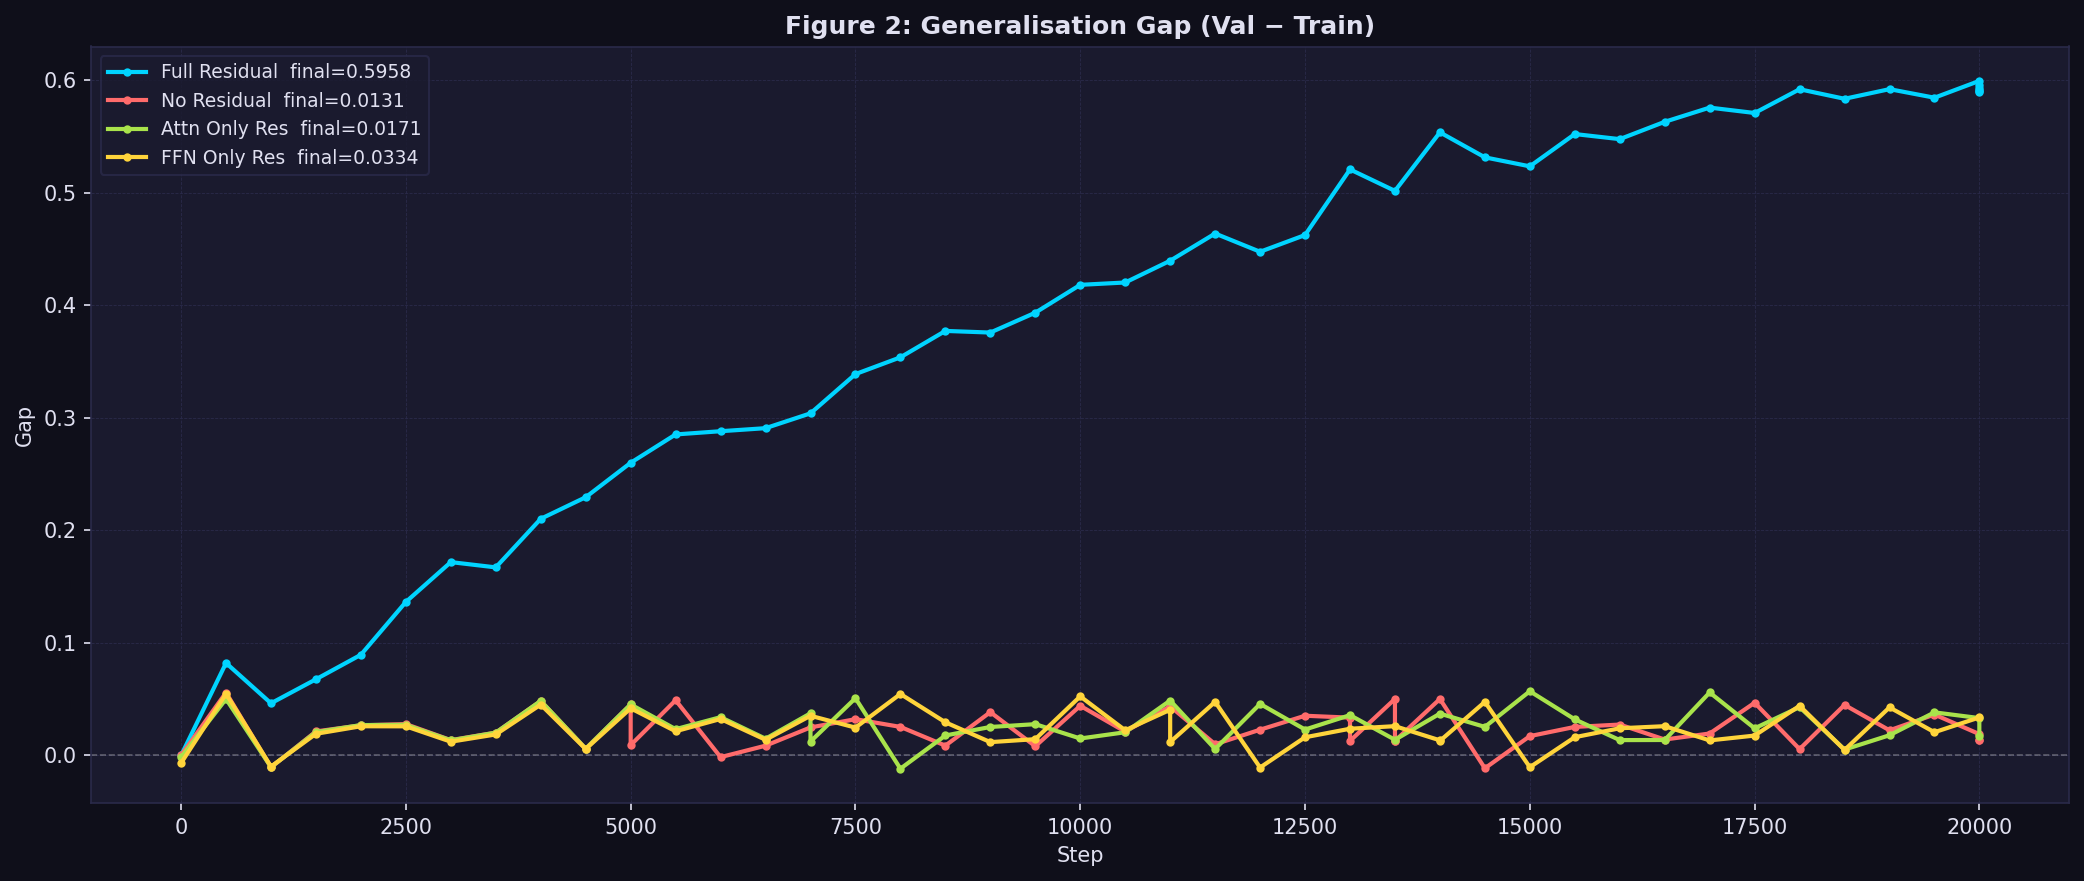

 PUB_fig2_gen_gap.png → /workspace/ResidualExperiment/figures/PUB_fig2_gen_gap.png


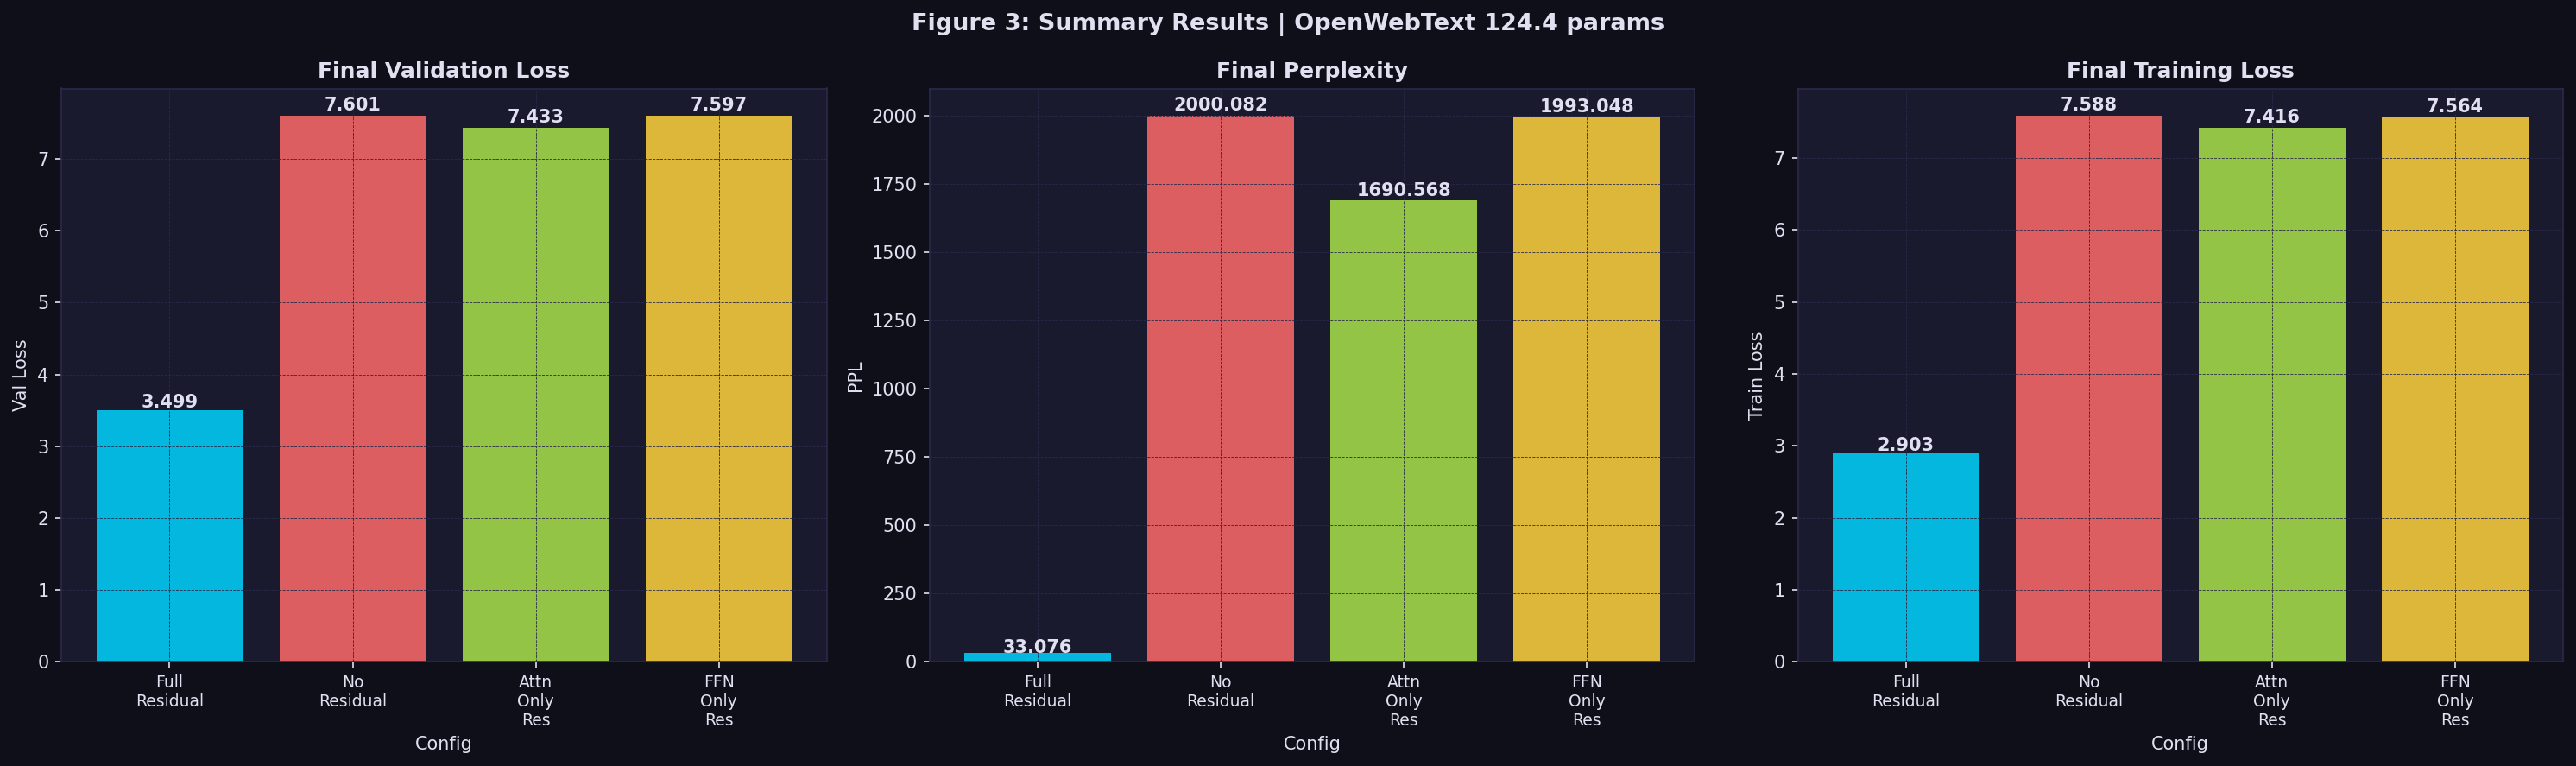

 PUB_fig3_summary.png → /workspace/ResidualExperiment/figures/PUB_fig3_summary.png


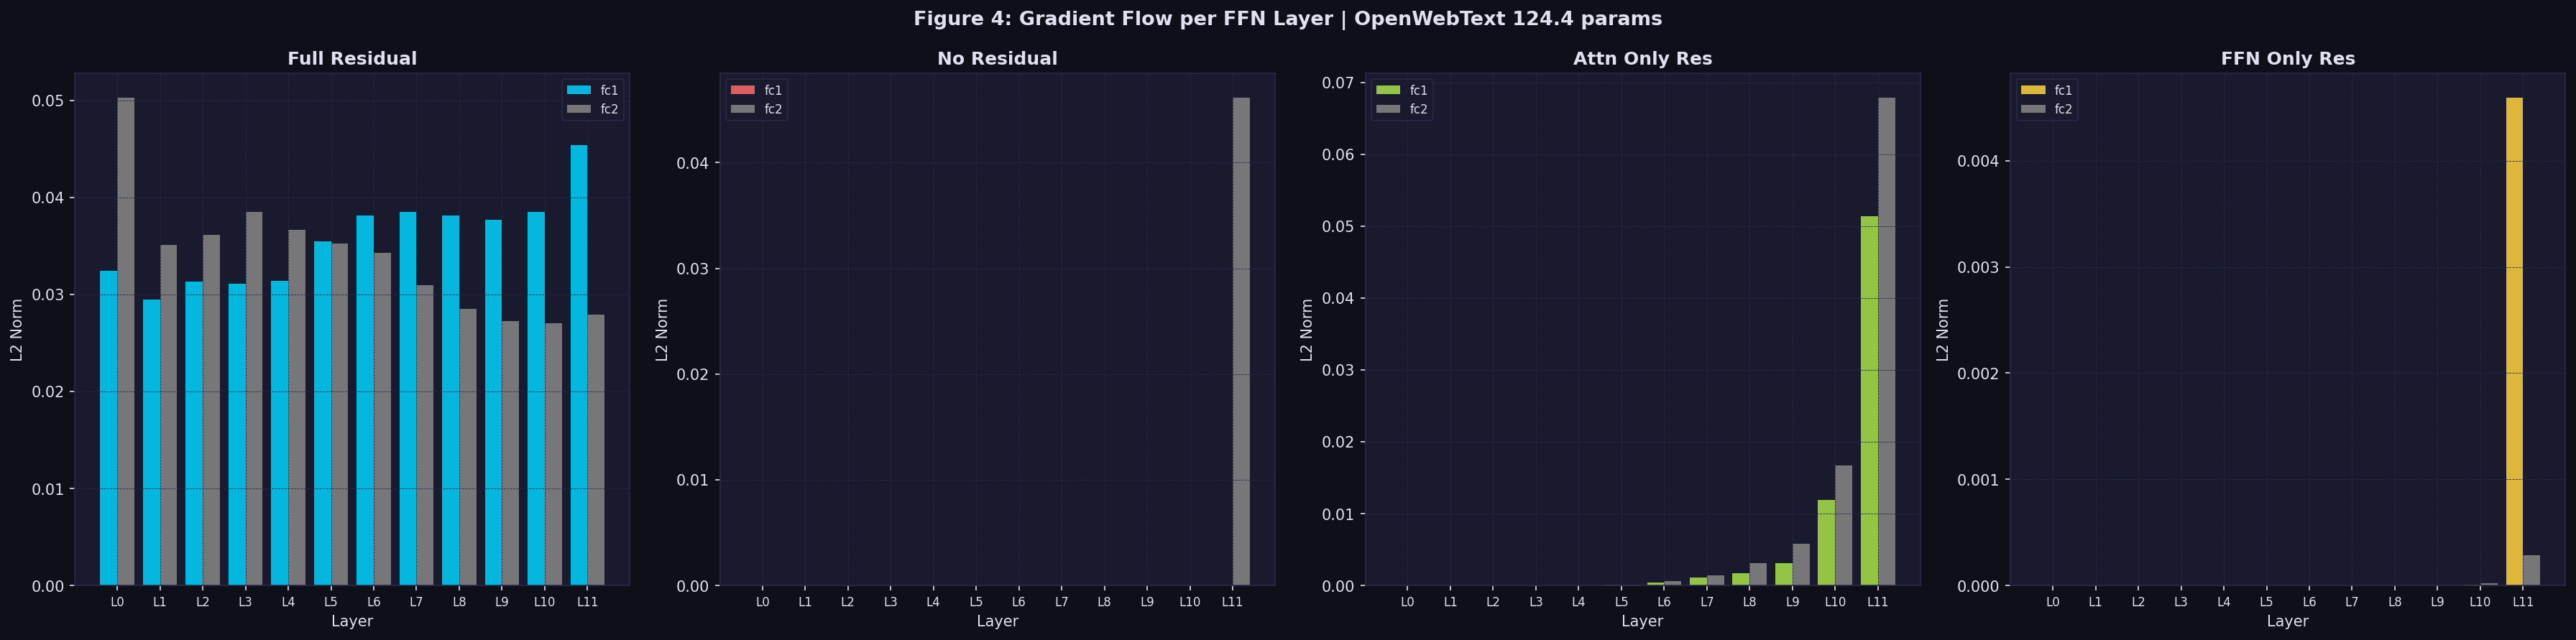

 PUB_fig4_gradient_flow.png → /workspace/ResidualExperiment/figures/PUB_fig4_gradient_flow.png


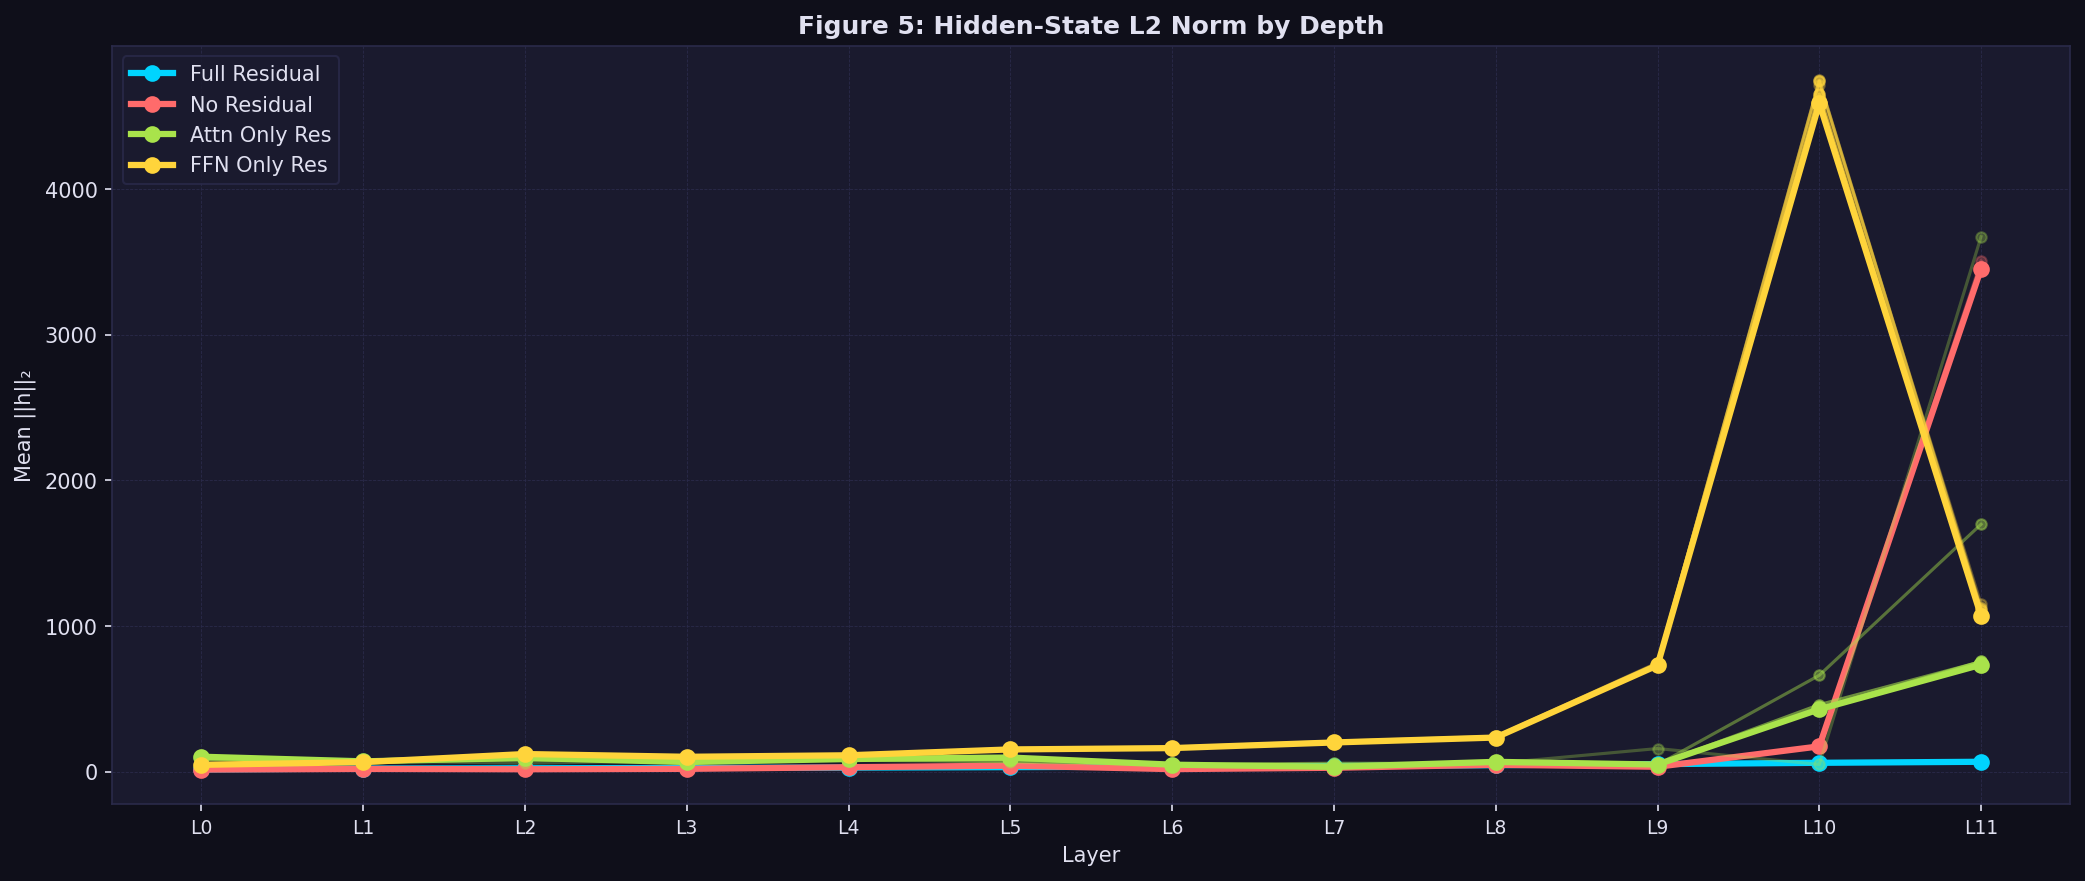

 PUB_fig5_hidden_norms.png → /workspace/ResidualExperiment/figures/PUB_fig5_hidden_norms.png

 All 5 publication figures saved to Google Drive
   Location: /workspace/ResidualExperiment/figures/

 Final Results Summary:
Config                 |   Val Loss |      PPL |      Train
──────────────────────────────────────────────────────────
Full Residual          |     3.4988 |     33.1 |     2.9030
No Residual            |     7.6009 |   2000.1 |     7.5878
Attn Only Res          |     7.4328 |   1690.6 |     7.4157
FFN Only Res           |     7.5974 |   1993.0 |     7.5641


In [16]:
results_file = os.path.join(RESULTS_DIR,'residual_results_owt.json')
with open(results_file) as f:
    all_results=json.load(f)

NAMES  = [n for n in [c['name'] for c in CONFIGS] if n in all_results]
COLORS = {n:next(c['color'] for c in CONFIGS if c['name']==n) for n in NAMES}

def pub_style(ax,title,xlabel='Step',ylabel=''):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(GRID)
    ax.tick_params(colors=TXT)
    ax.grid(True,color=GRID,lw=0.4,linestyle='--')
    ax.set_title(title,color=TXT,fontsize=12,fontweight='bold')
    if xlabel: ax.set_xlabel(xlabel,color=TXT)
    if ylabel: ax.set_ylabel(ylabel,color=TXT)

def savepub(fig,fname):
    path=os.path.join(FIG_DIR,fname)
    fig.savefig(path,dpi=150,bbox_inches='tight',facecolor=BG)
    plt.close(fig)
    try: display(IPImage(path))
    except: pass
    print(f' {fname} → {path}')

# Fig 1: Train/Val Loss
fig,axes=plt.subplots(1,2,figsize=(18,6)); fig.patch.set_facecolor(BG)
for ax,key,fk,title in [
    (axes[0],'train_losses','final_train','Training Loss'),
    (axes[1],'val_losses',  'final_val',  'Validation Loss')]:
    pub_style(ax,f'Figure 1: {title}',ylabel='Loss')
    for n,res in all_results.items():
        ax.plot(res['iters_log'],res[key],color=COLORS[n],lw=2,
                label=f'{n.replace("_"," ")} → {res[fk]:.4f}')
    ax.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=9)
fig.suptitle('Figure 1: Train/Val Loss | OpenWebText ~117M params',
             color=TXT,fontsize=13,fontweight='bold')
plt.tight_layout(); savepub(fig,'PUB_fig1_loss_curves.png')

# Fig 2: Generalisation gap
fig,ax=plt.subplots(figsize=(14,6)); fig.patch.set_facecolor(BG)
pub_style(ax,'Figure 2: Generalisation Gap (Val − Train)',ylabel='Gap')
ax.axhline(0,color='white',lw=0.8,linestyle='--',alpha=0.3)
for n,res in all_results.items():
    gap=[v-t for v,t in zip(res['val_losses'],res['train_losses'])]
    ax.plot(res['iters_log'],gap,color=COLORS[n],lw=2,marker='o',ms=3,
            label=f'{n.replace("_"," ")}  final={gap[-1]:.4f}')
ax.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=9)
plt.tight_layout(); savepub(fig,'PUB_fig2_gen_gap.png')

# Fig 3: Summary bar chart
fig,axes=plt.subplots(1,3,figsize=(20,6)); fig.patch.set_facecolor(BG)
for ax,metric,label,title in [
    (axes[0],'final_val',  'Val Loss',  'Final Validation Loss'),
    (axes[1],'final_ppl',  'PPL',       'Final Perplexity'),
    (axes[2],'final_train','Train Loss','Final Training Loss')]:
    pub_style(ax,title,xlabel='Config',ylabel=label)
    vals=[all_results[n][metric] for n in NAMES]
    bars=ax.bar(range(len(NAMES)),vals,
                color=[COLORS[n] for n in NAMES],alpha=0.85)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,
                f'{val:.3f}',ha='center',color=TXT,fontsize=10,fontweight='bold')
    ax.set_xticks(range(len(NAMES)))
    ax.set_xticklabels([n.replace('_','\n') for n in NAMES],color=TXT,fontsize=9)
fig.suptitle('Figure 3: Summary Results | OpenWebText 124.4 params',
             color=TXT,fontsize=13,fontweight='bold')
plt.tight_layout(); savepub(fig,'PUB_fig3_summary.png')

# Fig 4: Gradient flow per config
fig,axes=plt.subplots(1,len(NAMES),figsize=(6*len(NAMES),6))
fig.patch.set_facecolor(BG)
if len(NAMES)==1: axes=[axes]
for ax,name in zip(axes,NAMES):
    pub_style(ax,name.replace('_',' '),xlabel='Layer',ylabel='L2 Norm')
    latest=all_results[name]['grad_norm_history'][-1]
    layers=sorted(latest.keys(),key=int); x=np.arange(len(layers))
    ax.bar(x-0.2,[latest[l]['fc1'] for l in layers],0.4,
           color=COLORS[name],alpha=0.85,label='fc1')
    ax.bar(x+0.2,[latest[l]['fc2'] for l in layers],0.4,
           color='#888',alpha=0.85,label='fc2')
    ax.set_xticks(x)
    ax.set_xticklabels([f'L{l}' for l in layers],color=TXT,fontsize=8)
    ax.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=8)
fig.suptitle('Figure 4: Gradient Flow per FFN Layer | OpenWebText 124.4 params',
             color=TXT,fontsize=13,fontweight='bold')
plt.tight_layout(); savepub(fig,'PUB_fig4_gradient_flow.png')

# Fig 5: Hidden state norms
fig,ax=plt.subplots(figsize=(14,6)); fig.patch.set_facecolor(BG)
pub_style(ax,'Figure 5: Hidden-State L2 Norm by Depth',
          xlabel='Layer',ylabel='Mean ||h||₂')
for name,res in all_results.items():
    for i,snap in enumerate(res['hidden_norm_history'][-5:]):
        lyrs=sorted(snap.keys(),key=int)
        ax.plot(range(len(lyrs)),[snap[l] for l in lyrs],
                color=COLORS[name],alpha=0.3+0.14*i,lw=1.5,marker='o',ms=5)
    snap=res['hidden_norm_history'][-1]; lyrs=sorted(snap.keys(),key=int)
    ax.plot(range(len(lyrs)),[snap[l] for l in lyrs],
            color=COLORS[name],lw=3,marker='o',ms=7,
            label=name.replace('_',' '))
ax.set_xticks(range(len(lyrs)))
ax.set_xticklabels([f'L{l}' for l in lyrs],color=TXT,fontsize=9)
ax.legend(facecolor=PANEL,edgecolor=GRID,labelcolor=TXT,fontsize=10)
plt.tight_layout(); savepub(fig,'PUB_fig5_hidden_norms.png')

print(f'\n All 5 publication figures saved to Google Drive')
print(f'   Location: {FIG_DIR}')
print('\n Final Results Summary:')
print(f'{"Config":<22} | {"Val Loss":>10} | {"PPL":>8} | {"Train":>10}')
print('─'*58)
for name,res in all_results.items():
    if res.get('complete'):
        print(f'{name.replace("_"," "):<22} | '
              f'{res["final_val"]:>10.4f} | '
              f'{res["final_ppl"]:>8.1f} | '
              f'{res["final_train"]:>10.4f}')


In [17]:
import json
with open('/workspace/ResidualExperiment/results/residual_results_owt.json') as f:
    data = json.load(f)

print(f'{"Config":<22} | {"Val Loss":>10} | {"PPL":>8}')
print('-' * 45)
for name, res in data.items():
    if res.get('complete'):
        v = res['final_val']
        p = res['final_ppl']
        print(f'{name:<22} | {v:>10.4f} | {p:>8.1f}')

Config                 |   Val Loss |      PPL
---------------------------------------------
Full_Residual          |     3.4988 |     33.1
No_Residual            |     7.6009 |   2000.1
Attn_Only_Res          |     7.4328 |   1690.6
FFN_Only_Res           |     7.5974 |   1993.0
